# Key-to-Door: Decision Transformer Experiments

## Project Purpose

This project investigates **Decision Transformers (DT)** on a custom **Key-to-Door** environment - a 3-room grid world where an agent must:
1. **Room 0**: Pick up a key
2. **Room 1**: Wait/traverse (empty room)
3. **Room 2**: Open the door (only possible with the key)

The goal is to understand how DT performance is affected by:
- **Context size**: How much history the model sees
- **Data quality**: Quality of demonstration trajectories
- **Generalization**: Ability to transfer to different grid sizes

## Setup

In [21]:

# Setup - Add project to path and import dependencies
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))  # Add K2D root
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))

import numpy as np
from d3rlpy.algos.transformer.inputs import TransformerInput

# Import project modules
from src.env.KeyToDoor import KeyToDoorEnv
from src.env.KeyToDoor_quality import KeyToDoorEnvQuality
from src.env.KeyToDoor_context import KeyToDoorEnvContext
from src.models.dt.train_dt import load_dt
from src.models.ppo.train_ppo import load_ppo

print("✓ Setup complete")

✓ Setup complete


In [22]:
# Helper functions: flatten_state, visualize_trajectory, evaluate_dt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def flatten_state(s, include_has_key=True):
    """Flatten dict state to numpy array for DT.
    include_has_key=True: 6-dim (room, pos_x, pos_y, has_key, key_x, key_y) - ENV1
    include_has_key=False: 4-dim (pos_x, pos_y, key_x, key_y) - ENV3 (no room, no has_key)
    """
    if include_has_key:
        return np.concatenate([
            np.array([s['room']], dtype=np.float32), 
            s['pos'].astype(np.float32), 
            np.array([s['has_key']], dtype=np.float32),
            s['key_pos'].astype(np.float32)
        ])
    else:
        return np.concatenate([
            s['pos'].astype(np.float32),
            s['key_pos'].astype(np.float32)
        ])

def visualize_trajectory(trajectory, grid_size, title="Agent Trajectory"):
    """
    Visualize agent path through all 3 rooms side by side.
    Shows: path with step numbers, key position, key pickup location, door.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    room_names = ['Room 0 (Key)', 'Room 1 (Empty)', 'Room 2 (Door)']
    
    for room_idx, ax in enumerate(axes):
        ax.set_xlim(-0.5, grid_size - 0.5)
        ax.set_ylim(-0.5, grid_size - 0.5)
        ax.set_aspect('equal')
        ax.set_title(room_names[room_idx], fontsize=14, fontweight='bold')
        
        # Draw grid
        for i in range(grid_size + 1):
            ax.axhline(y=i - 0.5, color='lightgray', linewidth=0.5)
            ax.axvline(x=i - 0.5, color='lightgray', linewidth=0.5)
        
        # Draw path for this room
        path = trajectory['room_paths'].get(room_idx, [])
        if path:
            xs = [p[1] for p in path]  # col = x
            ys = [p[0] for p in path]  # row = y
            
            # For Room 2 with success: extend path to door
            if room_idx == 2 and trajectory['success']:
                door_pos = trajectory['door_pos']
                xs.append(door_pos[1])
                ys.append(door_pos[0])
            
            # Draw path line
            ax.plot(xs, ys, 'b-', linewidth=2, alpha=0.6, zorder=2)
            
            # Mark start (green circle)
            ax.scatter([xs[0]], [ys[0]], c='green', s=200, marker='o', zorder=3)
            
            # Mark end (blue square) - at door if success in room 2
            ax.scatter([xs[-1]], [ys[-1]], c='blue', s=200, marker='s', zorder=3)
            
            # Draw step numbers along path (except the added door point)
            num_steps = len(path)  # Original path length
            for i, (x, y) in enumerate(zip(xs[:num_steps], ys[:num_steps])):
                ax.annotate(str(i), (x, y), fontsize=7, ha='center', va='center', 
                           color='white', fontweight='bold', zorder=4)
        
        # Room 0: Draw key position
        if room_idx == 0:
            key_pos = trajectory['key_pos']
            ax.scatter([key_pos[1]], [key_pos[0]], c='gold', s=400, marker='*', 
                      zorder=5, edgecolors='orange', linewidths=2)
            ax.annotate('KEY', (key_pos[1], key_pos[0] + 0.7), fontsize=9, 
                       ha='center', color='orange', fontweight='bold')
            
            # Mark where key was picked up
            if trajectory.get('key_pickup_pos') is not None:
                pickup = trajectory['key_pickup_pos']
                ax.scatter([pickup[1]], [pickup[0]], c='lime', s=200, marker='^', zorder=6)
                ax.annotate('PICK', (pickup[1], pickup[0] - 0.7), fontsize=8, 
                           ha='center', color='lime', fontweight='bold')
        
        # Room 2: Draw door position
        if room_idx == 2:
            door_pos = trajectory['door_pos']
            color = 'green' if trajectory['success'] else 'red'
            ax.scatter([door_pos[1]], [door_pos[0]], c=color, s=400, marker='D', 
                      zorder=5, edgecolors='black', linewidths=2)
            ax.annotate('DOOR', (door_pos[1], door_pos[0] + 0.7), fontsize=9, 
                       ha='center', color=color, fontweight='bold')
        
        ax.set_xticks(range(grid_size))
        ax.set_yticks(range(grid_size))
        ax.invert_yaxis()  # Row 0 at top
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
    
    # Legend
    legend_elements = [
        mpatches.Patch(color='green', label='Start'),
        mpatches.Patch(color='blue', label='End'),
        mpatches.Patch(color='gold', label='Key'),
        mpatches.Patch(color='lime', label='Key Pickup'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10)
    
    # Use text instead of emojis for matplotlib compatibility
    status = "SUCCESS" if trajectory['success'] else "FAILED"
    color = 'green' if trajectory['success'] else 'red'
    fig.suptitle(f"{title} | {status} | Reward: {trajectory['reward']:.2f}", 
                fontsize=14, fontweight='bold', color=color)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

def evaluate_dt(env, model, target_return=10.0, context_size=20, verbose=True, visualize=False, title="", include_has_key=True):
    """Evaluate a Decision Transformer model with optional visualization.
    include_has_key: True for ENV1 (6-dim), False for ENV3 (5-dim)
    """
    state, _ = env.reset()
    done = False
    cumulative_reward = 0
    grid_size = env.observation_space['pos'].high[0] + 1
    
    observations, actions, rewards, returns_to_go, timesteps = [], [], [], [], []
    step = 0
    current_rtg = target_return
    action_names = ['up', 'down', 'left', 'right', 'pick']
    
    # Track trajectory for visualization
    room_paths = {0: [], 1: [], 2: []}
    key_pos = state['key_pos'].copy()
    key_pickup_pos = None
    door_pos = np.array([0, grid_size // 2])
    
    # Track has_key manually (ENV3 doesn't expose it or room in observation)
    has_key_tracking = state.get('has_key', getattr(env, 'has_key', 0))
    
    # Record initial position (use env.room if not in obs)
    current_room = state.get('room', getattr(env, 'room', 0))
    room_paths[current_room].append(state['pos'].copy())
    
    while not done:
        flat_state = flatten_state(state, include_has_key=include_has_key)
        observations.append(flat_state)
        returns_to_go.append(current_rtg)
        timesteps.append(step)
        
        ctx_start = max(0, len(observations) - context_size)
        obs_array = np.array(observations[ctx_start:], dtype=np.float32)
        rtg_array = np.array(returns_to_go[ctx_start:], dtype=np.float32)[:, np.newaxis]
        ts_array = np.array(timesteps[ctx_start:], dtype=np.int32)
        padded_rewards = rewards[ctx_start:] + [0.0]
        rew_array = np.array(padded_rewards, dtype=np.float32)[:, np.newaxis]
        padded_actions = [int(a) % 5 for a in actions[ctx_start:]] + [0]
        act_array = np.array(padded_actions, dtype=np.int32)
        
        inpt = TransformerInput(
            observations=obs_array, actions=act_array, rewards=rew_array,
            returns_to_go=rtg_array, timesteps=ts_array
        )
        
        prev_has_key = has_key_tracking
        prev_room = current_room
        prev_pos = state['pos'].copy()
        
        raw_logits = model.predict(inpt)
        action = int(np.argmax(raw_logits))
        actions.append(action)
        
        state, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)
        
        # Update tracking from env internals (ENV3 doesn't expose room/has_key)
        current_room = state.get('room', getattr(env, 'room', prev_room))
        new_has_key = state.get('has_key', getattr(env, 'has_key', prev_has_key))
        
        # Track key pickup
        if prev_has_key == 0 and new_has_key == 1:
            key_pickup_pos = prev_pos
        has_key_tracking = new_has_key
        
        # Record new position
        room_paths[current_room].append(state['pos'].copy())
        
        if verbose:
            print(f"Step {step}: Room {current_room}, Action: {action_names[action]}, Has Key: {has_key_tracking}")
        
        cumulative_reward += reward
        current_rtg = target_return - cumulative_reward
        step += 1
        done = terminated or truncated
    
    # Visualize if requested
    if visualize:
        trajectory = {
            'room_paths': room_paths,
            'key_pos': key_pos,
            'key_pickup_pos': key_pickup_pos,
            'door_pos': door_pos,
            'success': cumulative_reward > 0,
            'reward': cumulative_reward
        }
        visualize_trajectory(trajectory, grid_size, title=title if title else "DT Agent")
    
    else:
        print(f"\n✓ Episode finished | Total Reward: {cumulative_reward:.2f} | Steps: {step}")
    return cumulative_reward

def evaluate_ppo(env, model, verbose=True, visualize=False, title=""):
    """Evaluate a PPO model with optional visualization.
    PPO uses the raw dict observation directly (MultiInputPolicy).
    """
    state, _ = env.reset()
    done = False
    cumulative_reward = 0
    grid_size = env.observation_space['pos'].high[0] + 1
    step = 0
    action_names = ['up', 'down', 'left', 'right', 'pick']

    # Track trajectory for visualization
    room_paths = {0: [], 1: [], 2: []}
    key_pos = state['key_pos'].copy()
    key_pickup_pos = None
    door_pos = np.array([0, grid_size // 2])
    has_key_tracking = state.get('has_key', getattr(env, 'has_key', 0))

    # Record initial position
    current_room = state.get('room', getattr(env, 'room', 0))
    room_paths[current_room].append(state['pos'].copy())

    while not done:
        prev_has_key = has_key_tracking
        prev_pos = state['pos'].copy()

        action, _ = model.predict(state, deterministic=True)
        action = int(action)

        state, reward, terminated, truncated, _ = env.step(action)

        # Update tracking from env internals
        current_room = state.get('room', getattr(env, 'room', current_room))
        new_has_key = state.get('has_key', getattr(env, 'has_key', prev_has_key))
        if prev_has_key == 0 and new_has_key == 1:
            key_pickup_pos = prev_pos
        has_key_tracking = new_has_key

        # Record new position
        room_paths[current_room].append(state['pos'].copy())

        if verbose:
            print(f"Step {step}: Room {current_room}, Action: {action_names[action]}, Has Key: {has_key_tracking}")

        cumulative_reward += reward
        step += 1
        done = terminated or truncated

    # Visualize if requested
    if visualize:
        trajectory = {
            'room_paths': room_paths,
            'key_pos': key_pos,
            'key_pickup_pos': key_pickup_pos,
            'door_pos': door_pos,
            'success': cumulative_reward > 0,
            'reward': cumulative_reward
        }
        visualize_trajectory(trajectory, grid_size, title=title if title else "PPO Agent")
    else:
        print(f"\n✓ Episode finished | Total Reward: {cumulative_reward:.2f} | Steps: {step}")
    return cumulative_reward

print("✓ Helper functions defined (with visualization)")

✓ Helper functions defined (with visualization)


## Experiment 1: PPO Compare

### Explanation
How does a **Decision Transformer** (offline, sequence-modeling approach) compare to a **PPO** agent (online, policy-gradient approach) on the same Key-to-Door task?

**Question**: Can an offline DT match or beat an online-trained PPO agent?

**Setup**:
- Grid size: 10x10 (each room)
- **PPO**: Trained online with `stable-baselines3` (`models/PPO/ppo_room_size_10.zip`)
- **DT**: Trained offline on expert trajectories, context size 30 (`models/DT/context/dt_model_ctx30.d3`)
- Both evaluated on **ENV1 (Standard)**: 6-dim observation (room, pos_x, pos_y, has_key, key_x, key_y)

**Hypothesis**: PPO, even trained with direct environment interaction, should perform poorly. The DT, learning purely from offline trajectories, will outcome the PPO given high-quality data and sufficient context.

2026-02-18 22:01.35 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0
PPO COMPARE EXPERIMENT: PPO vs DT (context 30) on ENV1

--- PPO Agent ---


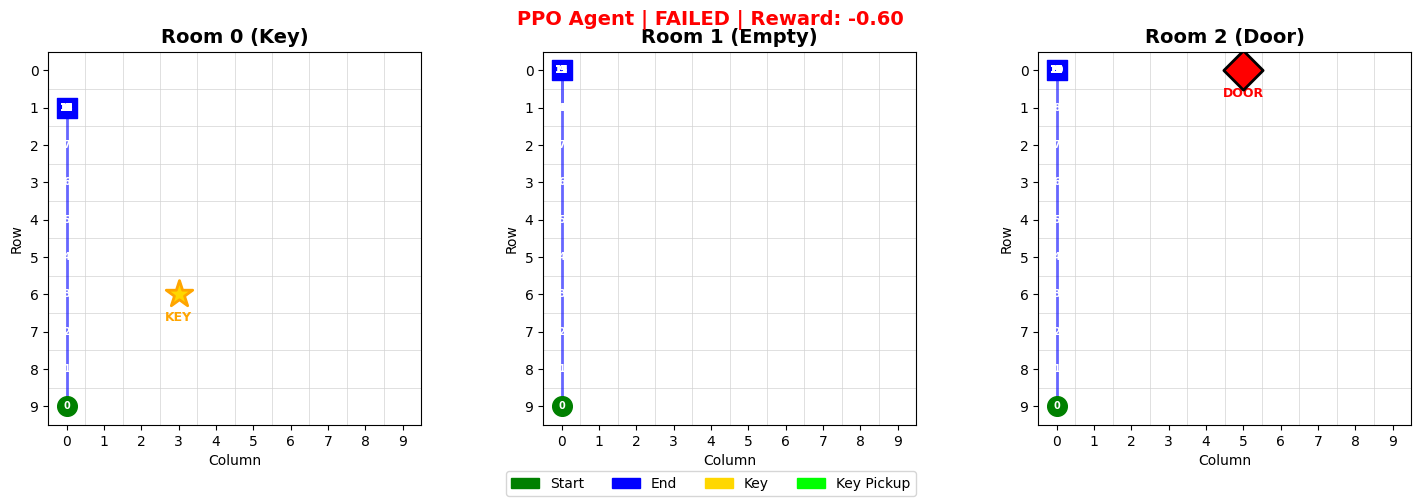


--- DT Agent (context 30) ---


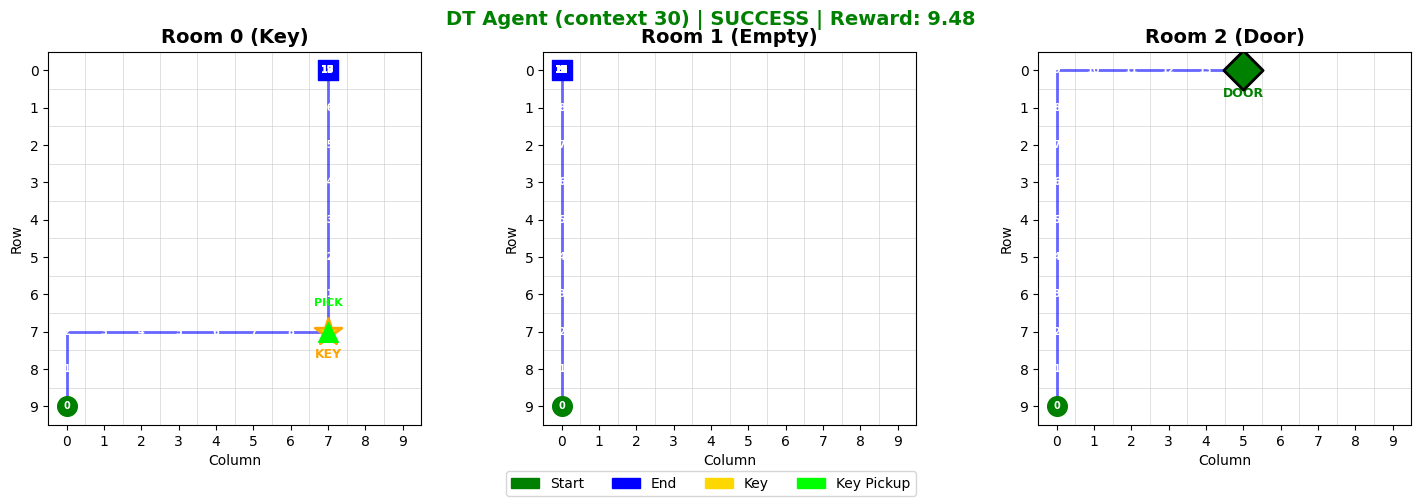


PPO COMPARE SUMMARY
Model                     | Reward          | Result    
-------------------------------------------------------
PPO                       | -0.60           | FAIL      
DT (context 30)           | 9.48            | OK        


In [23]:
# PPO Compare Experiment: PPO vs DT on ENV1 (10x10)
env1 = KeyToDoorEnv(n=10, render_mode=None)

# Load models
ppo_model = load_ppo("models/PPO/ppo_room_size_10.zip")
dt_model = load_dt("models/DT/context/dt_model_ctx30.d3")

print("=" * 70)
print("PPO COMPARE EXPERIMENT: PPO vs DT (context 30) on ENV1")
print("=" * 70)

# Evaluate PPO
print("\n--- PPO Agent ---")
ppo_reward = evaluate_ppo(env1, ppo_model, verbose=False, visualize=True, title="PPO Agent")

# Evaluate DT (context 30)
print("\n--- DT Agent (context 30) ---")
dt_reward = evaluate_dt(env1, dt_model, target_return=10.0, context_size=30,
                        verbose=False, visualize=True, title="DT Agent (context 30)",
                        include_has_key=True)

# Summary
print("\n" + "=" * 70)
print("PPO COMPARE SUMMARY")
print("=" * 70)
print(f"{'Model':<25} | {'Reward':<15} | {'Result':<10}")
print("-" * 55)
ppo_status = "OK" if ppo_reward and ppo_reward > 0 else "FAIL"
dt_status = "OK" if dt_reward and dt_reward > 0 else "FAIL"
print(f"{'PPO':<25} | {ppo_reward:<15.2f} | {ppo_status:<10}")
print(f"{'DT (context 30)':<25} | {dt_reward:<15.2f} | {dt_status:<10}")

## Experiment 2: Context Size


### Explanation
The **context size** determines how many previous steps the Decision Transformer can "see" when making a decision. 

**Question**: What is the optimal context window for the Key-to-Door task?

**Setup**:
- Grid size: 10×10 (each room)
- Context sizes tested: **10**, **30**, **60**
- ENV1 training: 1000 optimal trajectories
- ENV3 training: 1000 mixed trajectories (500 optimal + 500 skip-key)

**Environment Comparison**:
- **ENV1 (Standard)**: 6-dim observation (room, pos_x, pos_y, has_key, key_x, key_y)
- **ENV3 (Context Variant)**: 4-dim observation (pos_x, pos_y, key_x, key_y) - **no room, no has_key!**

**Hypothesis**: 
- ENV1: All context sizes should succeed (explicit room + has_key in observation)
- ENV3 with small context: Should FAIL - cannot see key pickup event from room 0 when deciding in room 2 (~30+ steps ago), cannot determine current room, and must distinguish successful vs failed trajectories in training data
- ENV3 with large context: Should SUCCEED - can see full trajectory including key pickup in room 0

CONTEXT EXPERIMENT: ENV1 (6-dim) vs ENV3 (4-dim, no room/has_key, mixed data)

--- ENV1 (Standard: 6-dim with room + has_key) ---
2026-02-18 22:05.54 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


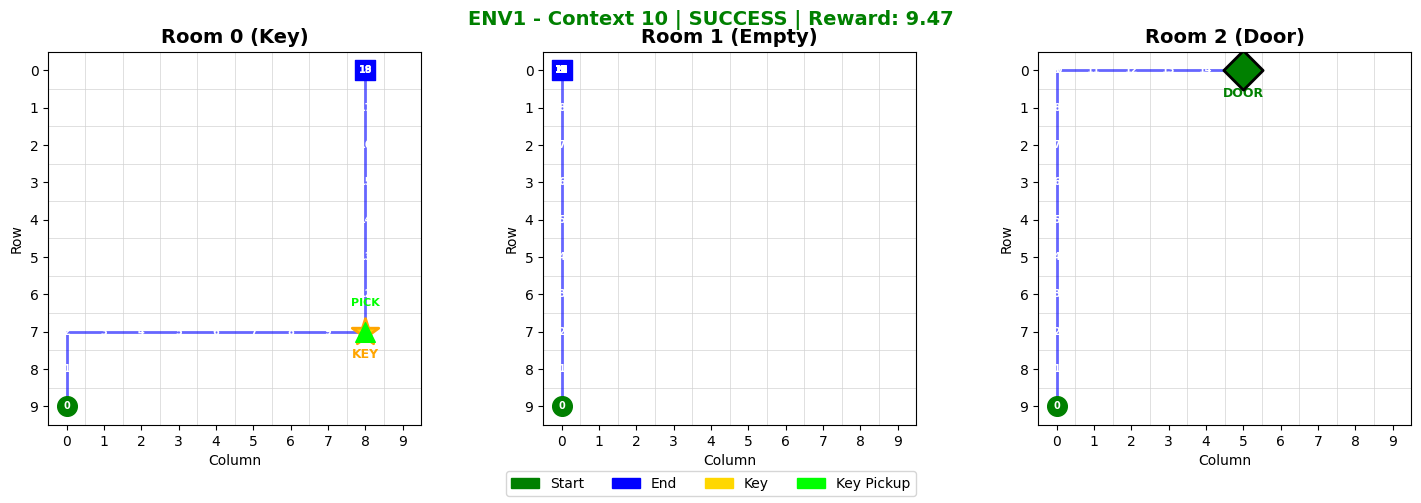

2026-02-18 22:05.58 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


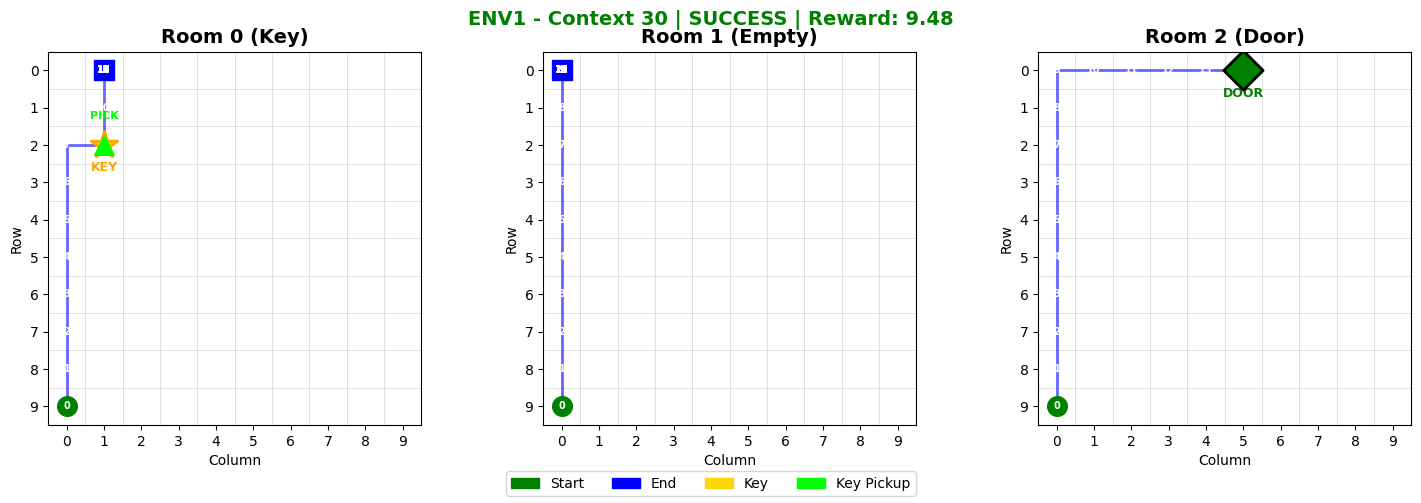

2026-02-18 22:06.02 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


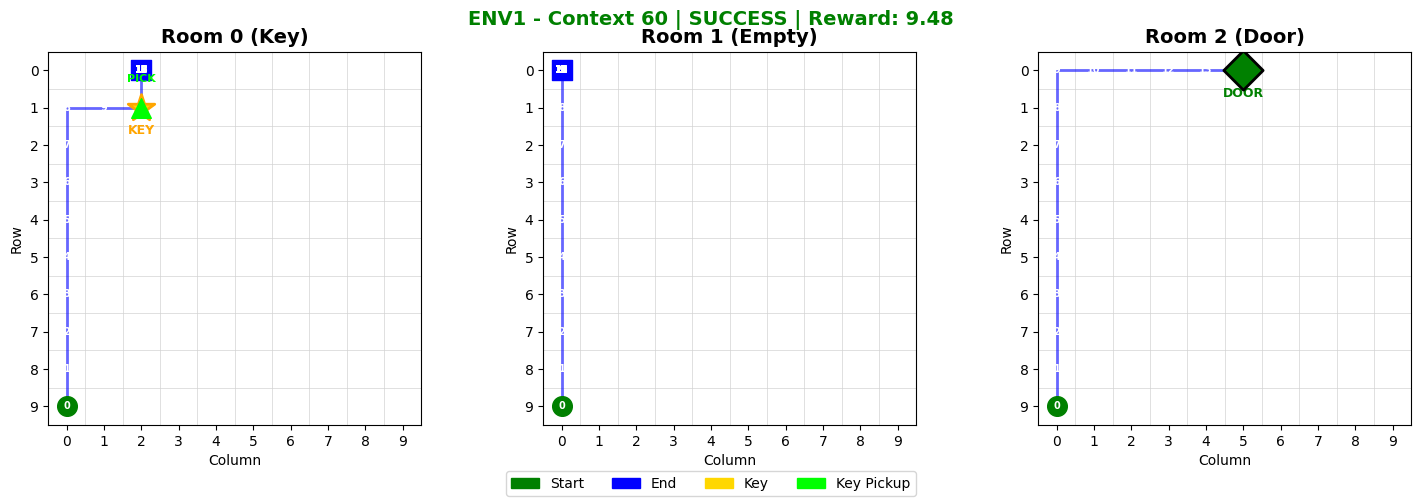


--- ENV3 (Context Variant: 4-dim, no room/has_key, mixed data) ---
2026-02-18 22:06.08 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


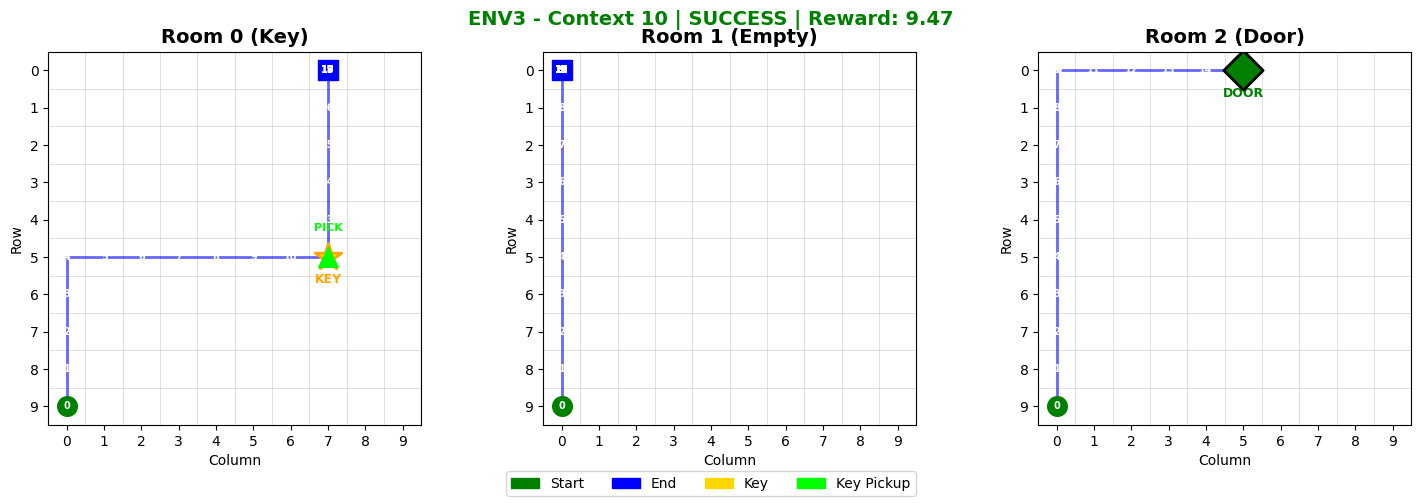

2026-02-18 22:06.11 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


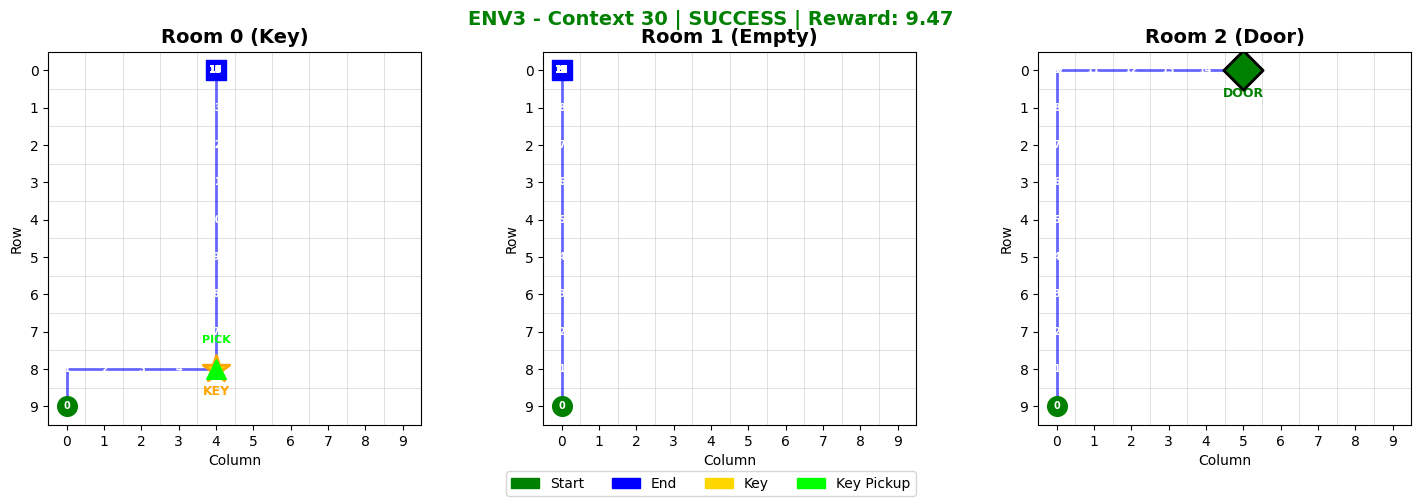

CONTEXT EXPERIMENT SUMMARY: ENV1 vs ENV3
Context    | ENV1 (6-dim, full obs)    | ENV3 (4-dim, mixed)      
-----------------------------------------------------------------
10         | 9.47 OK                   | 9.47 OK                  
30         | 9.48 OK                   | 9.47 OK                  
60         | 9.48 OK                   | N/A                      


In [31]:
# Context Experiment: Compare ENV1 (6-dim obs) vs ENV3 (4-dim obs, mixed data)
env1 = KeyToDoorEnv(n=10, render_mode=None)
env3 = KeyToDoorEnvContext(n=10, render_mode=None)

# ENV1 models (standard - 6-dim observation with room + has_key)
context_models_env1 = {
    10: "models/DT/context/dt_model_ctx10.d3",
    30: "models/DT/context/dt_model_ctx30.d3",
    60: "models/DT/context/dt_model_ctx60.d3"
}

# ENV3 models (context variant - 4-dim observation, no room, no has_key, mixed data)
context_models_env3 = {
    10: "models/DT/context_env3/dt_model_ctx10.d3",
    30: "models/DT/context_env3/dt_model_ctx30.d3",
}

print("=" * 70)
print("CONTEXT EXPERIMENT: ENV1 (6-dim) vs ENV3 (4-dim, no room/has_key, mixed data)")
print("=" * 70)

# Test ENV1 models
print("\n--- ENV1 (Standard: 6-dim with room + has_key) ---")
context_results_env1 = {}
for ctx_size, model_path in context_models_env1.items():
    model = load_dt(model_path)
    reward = evaluate_dt(env1, model, target_return=10.0, context_size=ctx_size, 
                        verbose=False, visualize=True, title=f"ENV1 - Context {ctx_size}",
                        include_has_key=True)
    context_results_env1[ctx_size] = reward

# Test ENV3 models (4-dim, trained on 50% optimal + 50% skip-key data)
print("\n--- ENV3 (Context Variant: 4-dim, no room/has_key, mixed data) ---")
context_results_env3 = {}
for ctx_size, model_path in context_models_env3.items():
    model = load_dt(model_path)
    reward = evaluate_dt(env3, model, target_return=10.0, context_size=ctx_size, 
                        verbose=False, visualize=True, title=f"ENV3 - Context {ctx_size}",
                        include_has_key=False)
    context_results_env3[ctx_size] = reward

# Summary comparison
print("" + "=" * 70)
print("CONTEXT EXPERIMENT SUMMARY: ENV1 vs ENV3")
print("=" * 70)
print(f"{'Context':<10} | {'ENV1 (6-dim, full obs)':<25} | {'ENV3 (4-dim, mixed)':<25}")
print("-" * 65)
for ctx_size in [10, 30, 60]:
    r1 = context_results_env1.get(ctx_size, None)
    r3 = context_results_env3.get(ctx_size, None)
    s1 = f"{r1:.2f} {'OK' if r1 and r1 > 0 else 'FAIL'}" if r1 is not None else "N/A"
    s3 = f"{r3:.2f} {'OK' if r3 and r3 > 0 else 'FAIL'}" if r3 is not None else "N/A"
    print(f"{ctx_size:<10} | {s1:<25} | {s3:<25}")

## Experiment 3: Data Quality

### Explanation
Decision Transformers learn from offline demonstration data. How does the **quality** of this data affect learning?

**Question**: Can DT learn from partially corrupted or random trajectories?

**Setup**:
- Grid size: 10×10
- Dataset types:
  - **Ground Truth**: Optimal policy, only winning trajectories
  - **Half Truth**: Mixed policy (1 room optimal, 2 rooms random actions)
  - **Random**: Completely random actions

**Environment Comparison**:
- **ENV1 (Standard)**: Full observation including key position
- **ENV2 (Quality Variant)**: Modified environment for quality experiments

**Hypothesis**: 
- Ground Truth should learn perfectly
- Random should fail completely
- Half Truth... will partial information help or confuse?

QUALITY EXPERIMENT: ENV1 (Standard) vs ENV2 (Quality Variant)

--- ENV1 (Standard Environment) ---


2026-02-18 22:01.55 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


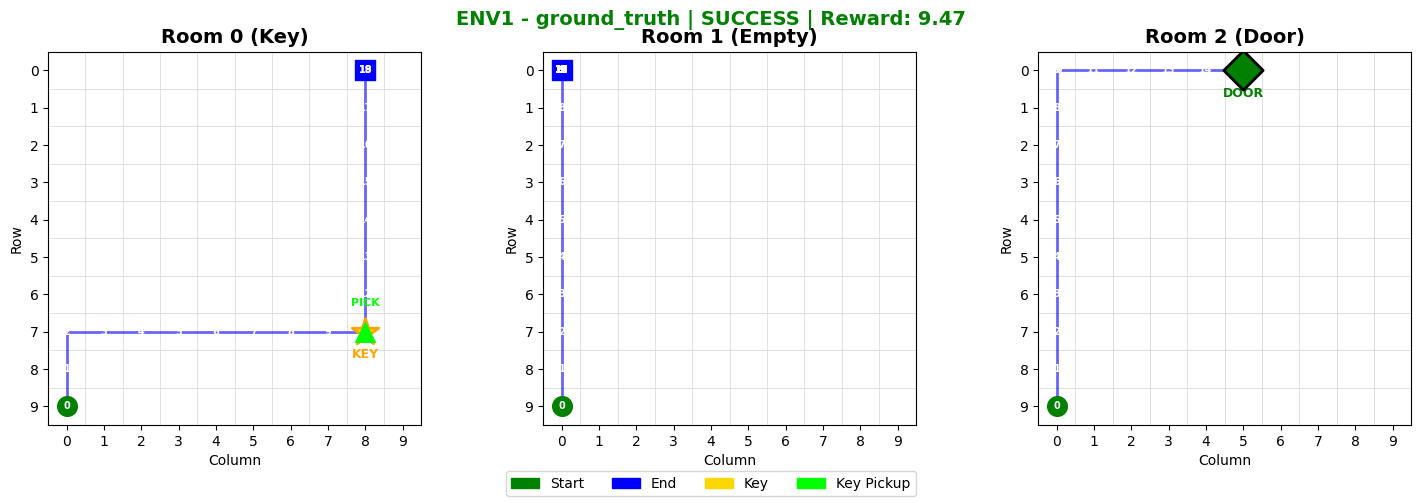

2026-02-18 22:02.00 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


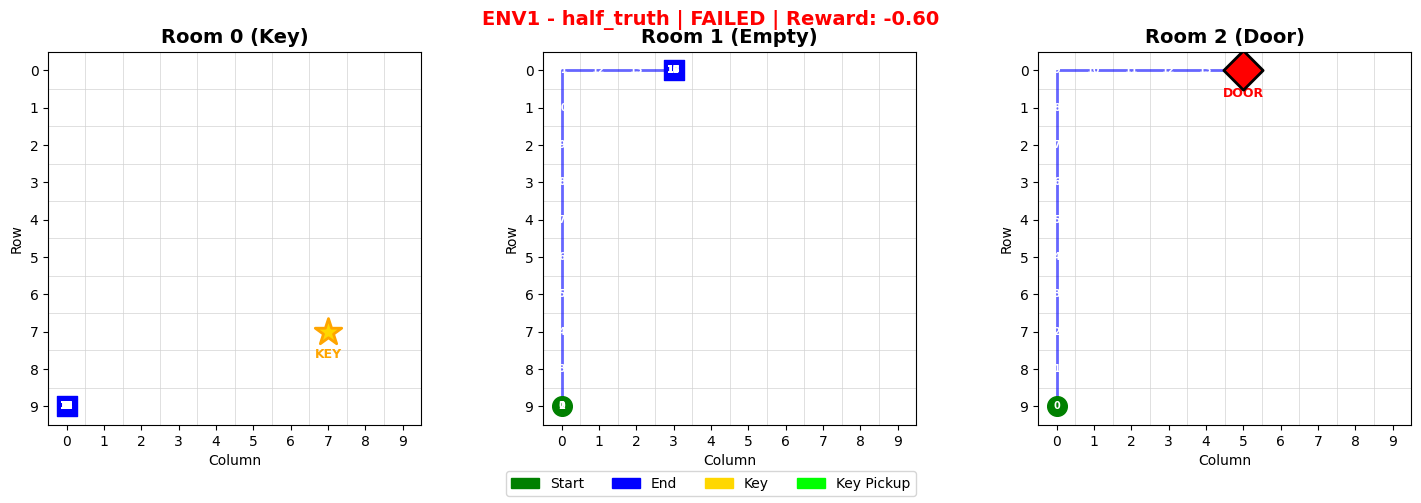

2026-02-18 22:02.04 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


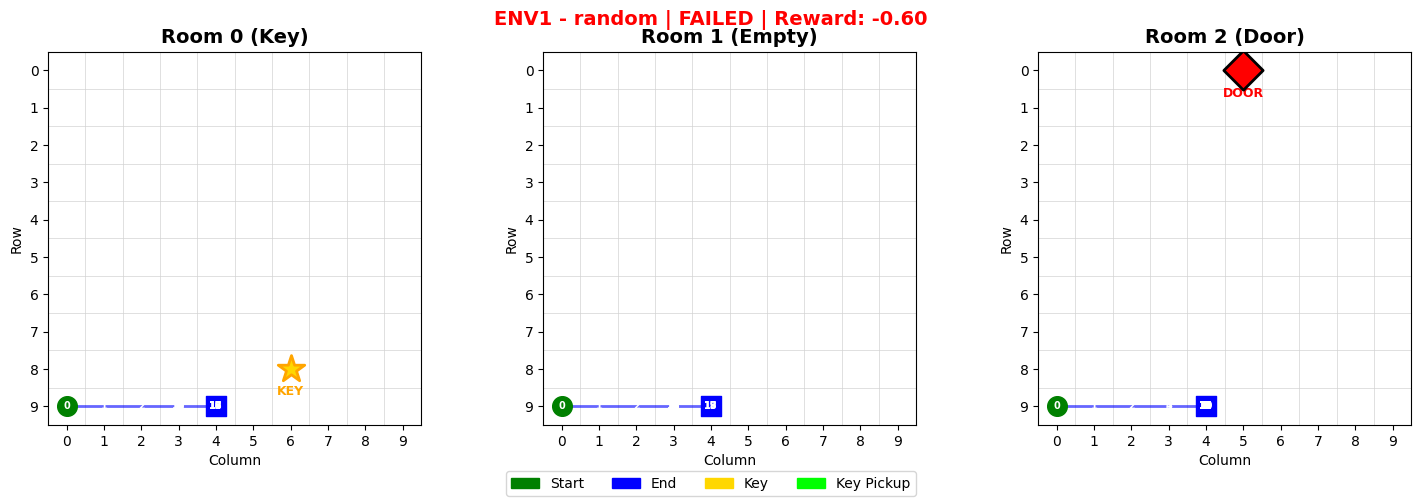


--- ENV2 (Quality Variant Environment) ---
2026-02-18 22:02.07 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


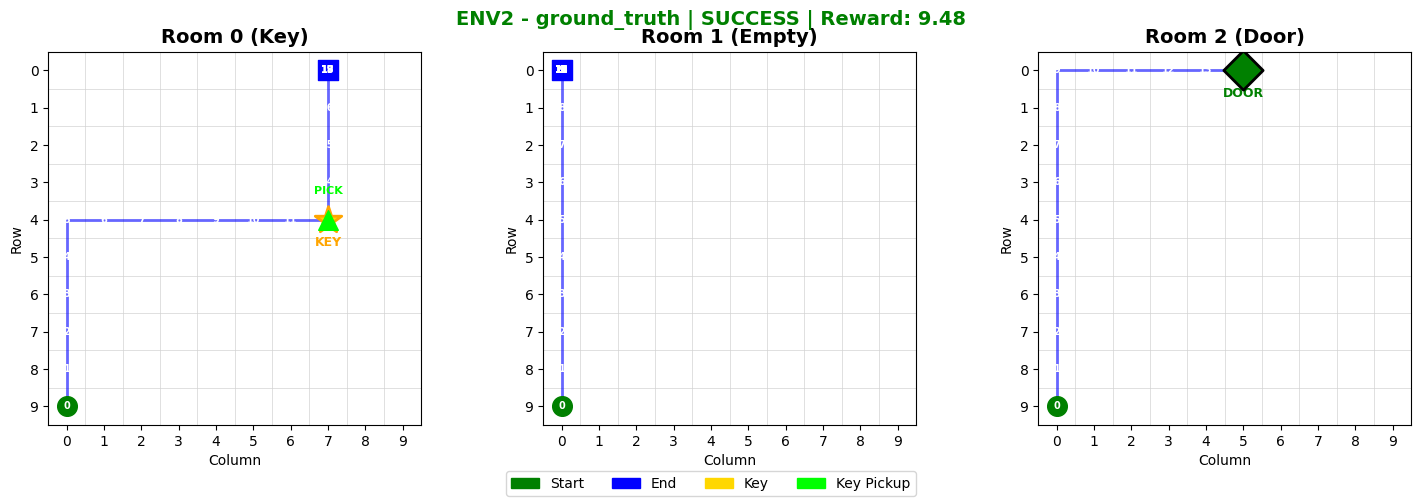

2026-02-18 22:02.10 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


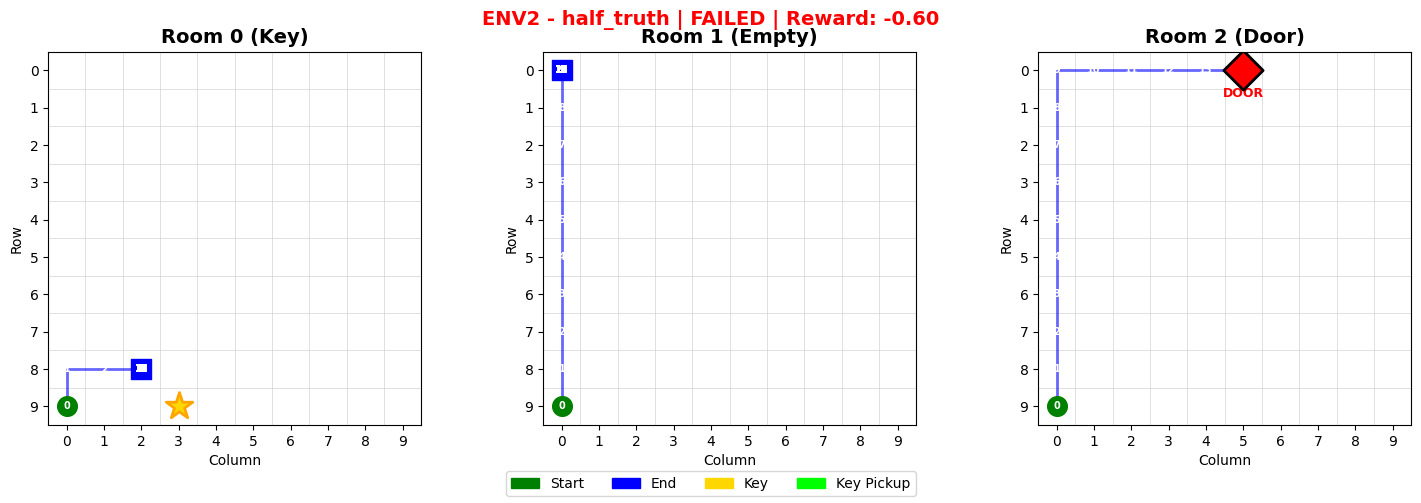

2026-02-18 22:02.13 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


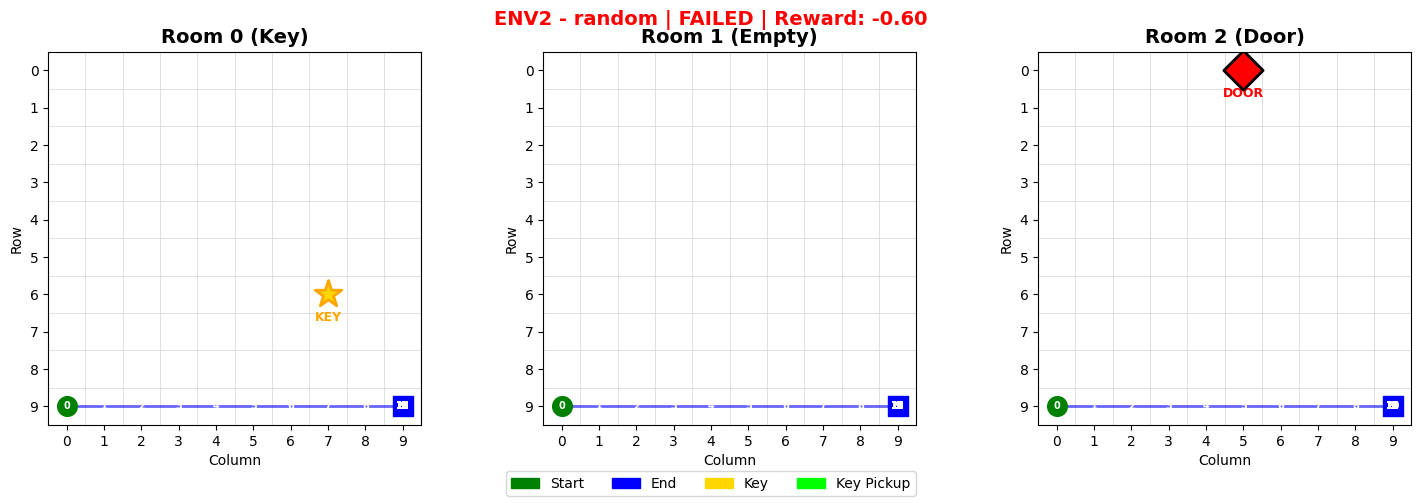


QUALITY EXPERIMENT SUMMARY: ENV1 vs ENV2
Dataset         | ENV1                 | ENV2                
------------------------------------------------------------
ground_truth    | 9.47 OK              | 9.48 OK             
half_truth      | -0.60 FAIL           | -0.60 FAIL          
random          | -0.60 FAIL           | -0.60 FAIL          


In [25]:
# Quality Experiment: Compare ENV1 vs ENV2
env1 = KeyToDoorEnv(n=10, render_mode=None)
env2 = KeyToDoorEnv(n=10, render_mode=None)

# ENV1 models (standard)
quality_models_env1 = {
    "ground_truth": "models/DT/quality/dt_model_ground_truth_10.d3",
    "half_truth": "models/DT/quality/dt_model_half_truth_10.d3",
    "random": "models/DT/quality/dt_model_random_10.d3"
}

# ENV2 models (quality variant)
quality_models_env2 = {
    "ground_truth": "models/DT/quality_env2/quality_env2/dt_model_ground_truth_10.d3",
    "half_truth": "models/DT/quality_env2/quality_env2/dt_model_half_truth_10.d3",
    "random": "models/DT/quality_env2/quality_env2/dt_model_random_10.d3"
}

print("=" * 70)
print("QUALITY EXPERIMENT: ENV1 (Standard) vs ENV2 (Quality Variant)")
print("=" * 70)

# Test ENV1 models
print("\n--- ENV1 (Standard Environment) ---")
quality_results_env1 = {}
for quality_type, model_path in quality_models_env1.items():
    model = load_dt(model_path)
    reward = evaluate_dt(env1, model, target_return=10.0, context_size=10, 
                        verbose=False, visualize=True, title=f"ENV1 - {quality_type}")
    quality_results_env1[quality_type] = reward

# Test ENV2 models
print("\n--- ENV2 (Quality Variant Environment) ---")
quality_results_env2 = {}
for quality_type, model_path in quality_models_env2.items():
    model = load_dt(model_path)
    reward = evaluate_dt(env2, model, target_return=10.0, context_size=10, 
                        verbose=False, visualize=True, title=f"ENV2 - {quality_type}")
    quality_results_env2[quality_type] = reward

# Summary comparison
print("\n" + "=" * 70)
print("QUALITY EXPERIMENT SUMMARY: ENV1 vs ENV2")
print("=" * 70)
print(f"{'Dataset':<15} | {'ENV1':<20} | {'ENV2':<20}")
print("-" * 60)
for quality_type in ["ground_truth", "half_truth", "random"]:
    r1 = quality_results_env1.get(quality_type, None)
    r2 = quality_results_env2.get(quality_type, None)
    s1 = f"{r1:.2f} {'OK' if r1 and r1 > 0 else 'FAIL'}" if r1 is not None else "N/A"
    s2 = f"{r2:.2f} {'OK' if r2 and r2 > 0 else 'FAIL'}" if r2 is not None else "N/A"
    print(f"{quality_type:<15} | {s1:<20} | {s2:<20}")

## Experiment 4: Generalization

### Explanation
Can a DT trained on **smaller grids** generalize to **larger grids**?

**Question**: Does observation normalization enable cross-grid transfer?

**Setup**:
- Training grids: 5×5 and 7×7 (with normalized observations: positions scaled to [0,1])
- Test grids: 
  - 7×7 (in-distribution)
  - 10×10 (out-of-distribution)

**Normalization**: `pos_normalized = pos / (grid_size - 1)` 
- This makes "corner" always = 1.0 regardless of grid size

**Hypothesis**: Normalization should help transfer, but extrapolation to much larger grids may still fail.

In [26]:
# Generalization: Need normalized evaluation function
def flatten_state_normalized(s, grid_size):
    """Flatten state with normalized positions for cross-grid generalization."""
    return np.array([
        s['room'] / 2.0,  # Normalize room to [0, 1]
        s['pos'][0] / (grid_size - 1),
        s['pos'][1] / (grid_size - 1),
        float(s['has_key']),
        s['key_pos'][0] / (grid_size - 1),
        s['key_pos'][1] / (grid_size - 1)
    ], dtype=np.float32)

def evaluate_dt_normalized(env, model, grid_size, target_return=10.0, context_size=20, 
                          verbose=True, visualize=False, title=""):
    """Evaluate DT with normalized observations and optional visualization."""
    state, _ = env.reset()
    done = False
    cumulative_reward = 0
    
    observations, actions, rewards, returns_to_go, timesteps = [], [], [], [], []
    step = 0
    current_rtg = target_return
    action_names = ['up', 'down', 'left', 'right', 'pick']
    
    # Track trajectory for visualization
    room_paths = {0: [], 1: [], 2: []}
    key_pos = state['key_pos'].copy()
    key_pickup_pos = None
    door_pos = np.array([0, grid_size // 2])
    room_paths[state['room']].append(state['pos'].copy())
    
    while not done:
        flat_state = flatten_state_normalized(state, grid_size)
        observations.append(flat_state)
        returns_to_go.append(current_rtg)
        timesteps.append(step)
        
        ctx_start = max(0, len(observations) - context_size)
        obs_array = np.array(observations[ctx_start:], dtype=np.float32)
        rtg_array = np.array(returns_to_go[ctx_start:], dtype=np.float32)[:, np.newaxis]
        ts_array = np.array(timesteps[ctx_start:], dtype=np.int32)
        padded_rewards = rewards[ctx_start:] + [0.0]
        rew_array = np.array(padded_rewards, dtype=np.float32)[:, np.newaxis]
        padded_actions = [int(a) % 5 for a in actions[ctx_start:]] + [0]
        act_array = np.array(padded_actions, dtype=np.int32)
        
        inpt = TransformerInput(
            observations=obs_array, actions=act_array, rewards=rew_array,
            returns_to_go=rtg_array, timesteps=ts_array
        )
        
        prev_has_key = state['has_key']
        prev_pos = state['pos'].copy()
        
        raw_logits = model.predict(inpt)
        action = int(np.argmax(raw_logits))
        actions.append(action)
        
        state, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)
        
        # Track key pickup
        if prev_has_key == 0 and state['has_key'] == 1:
            key_pickup_pos = prev_pos
        room_paths[state['room']].append(state['pos'].copy())
        
        if verbose:
            print(f"Step {step}: Room {state['room']}, Action: {action_names[action]}, Has Key: {state['has_key']}")
        
        cumulative_reward += reward
        current_rtg = target_return - cumulative_reward
        step += 1
        done = terminated or truncated
    
    if visualize:
        trajectory = {
            'room_paths': room_paths,
            'key_pos': key_pos,
            'key_pickup_pos': key_pickup_pos,
            'door_pos': door_pos,
            'success': cumulative_reward > 0,
            'reward': cumulative_reward
        }
        visualize_trajectory(trajectory, grid_size, title=title if title else "DT Agent (Normalized)")
    else:
        print(f"\n✓ Episode finished | Total Reward: {cumulative_reward:.2f} | Steps: {step}")
    return cumulative_reward

print("✓ Normalized evaluation function defined (with visualization)")

✓ Normalized evaluation function defined (with visualization)


GENERALIZATION EXPERIMENT
2026-02-18 22:03.05 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


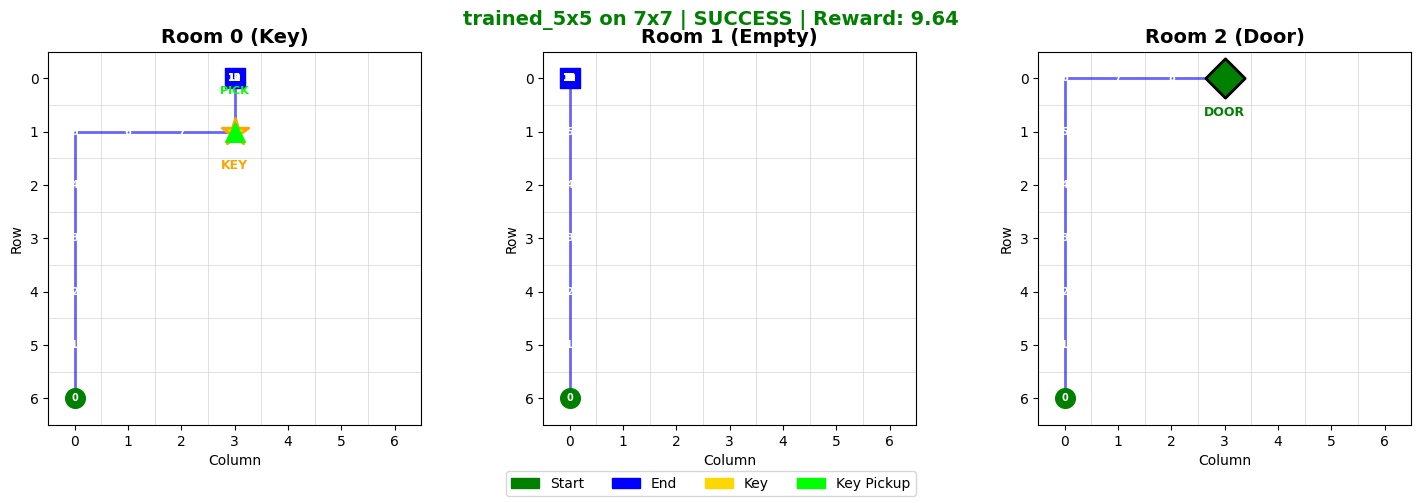

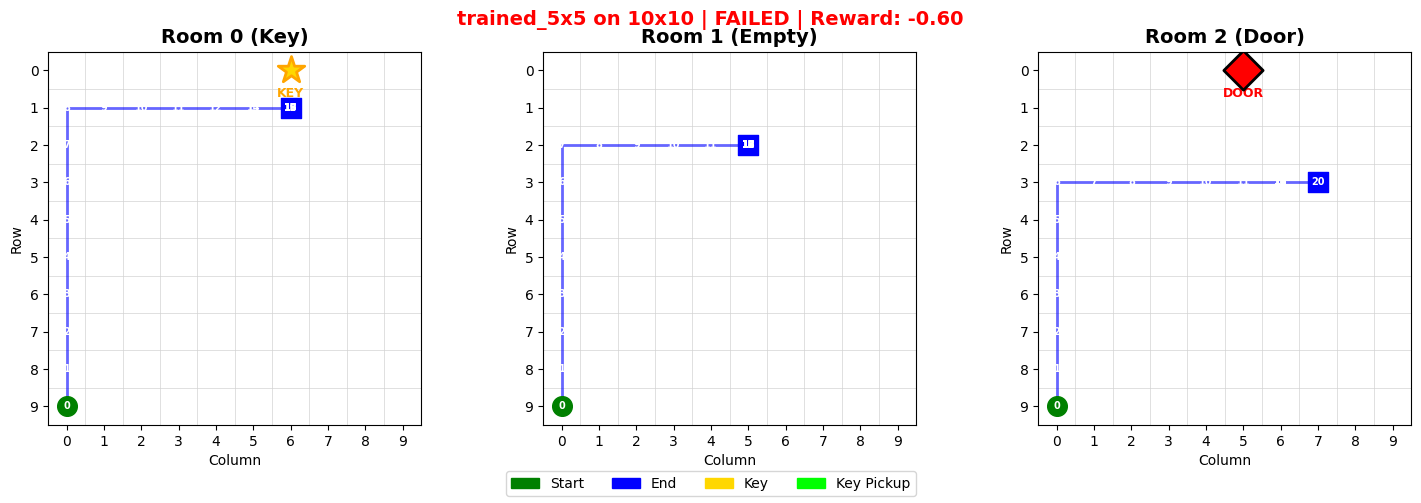

2026-02-18 22:03.09 [warning  ] There might be incompatibility because of version mismatch. current_version=2.8.1 saved_version=2.8.0


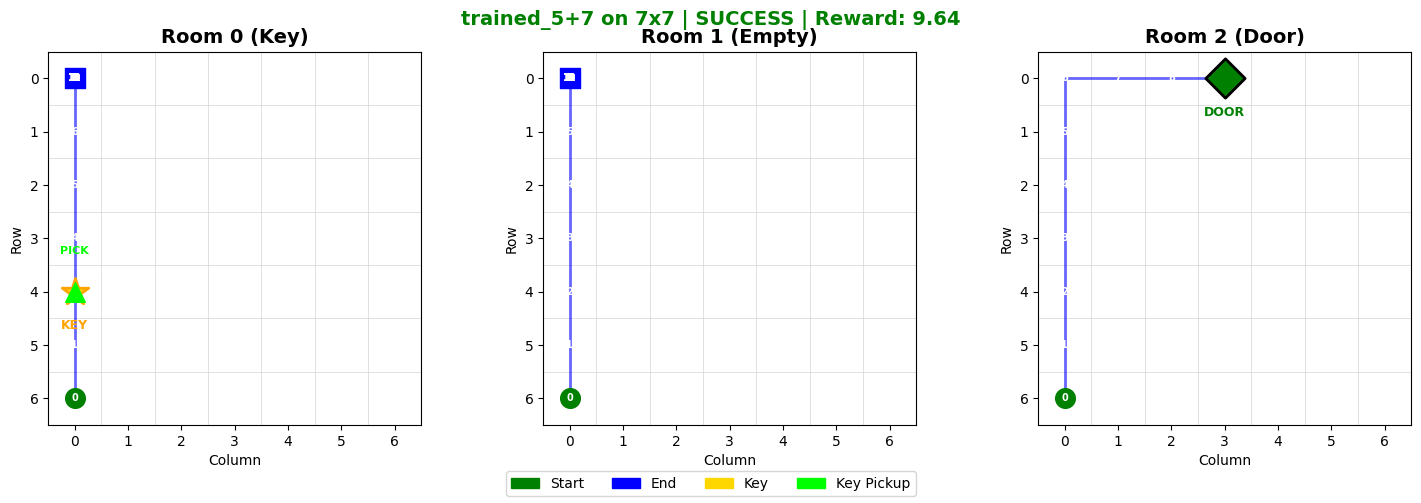

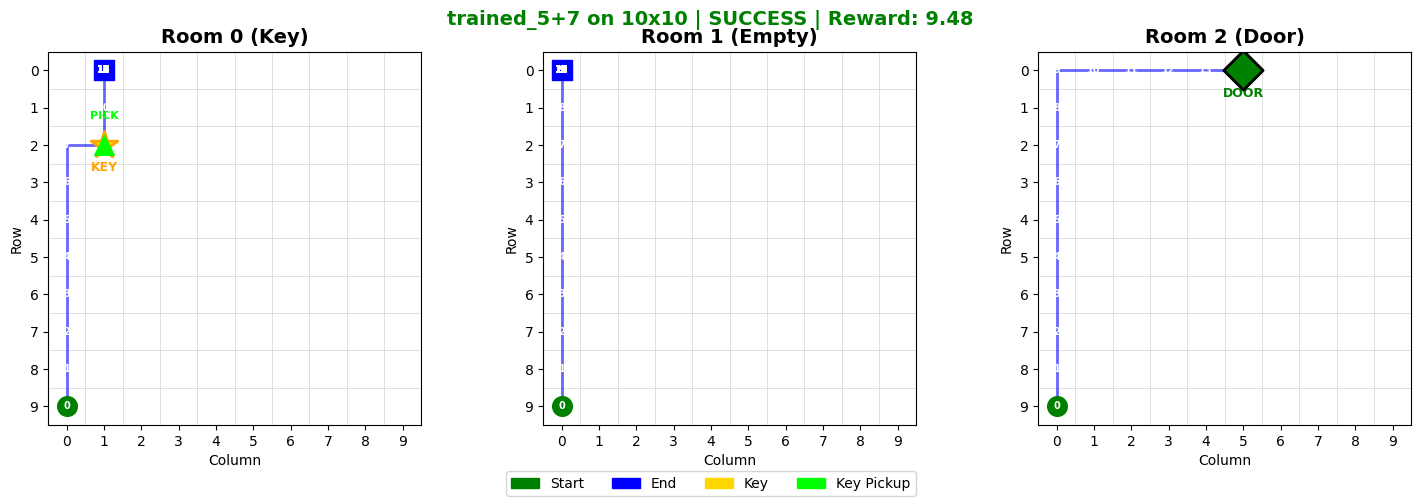

GENERALIZATION EXPERIMENT SUMMARY
Model           | 7x7 (in-dist)   | 10x10 (OOD)    
--------------------------------------------------
trained_5x5     |   9.64 ✅      |  -0.60 ❌     
trained_5+7     |   9.64 ✅      |   9.48 ✅     


In [28]:
# Generalization Experiment: Test cross-grid transfer
gen_models = {
    "trained_5x5": "models/DT/generalization/dt_model_ground_truth_5_norm.d3",
    "trained_5+7": "models/DT/generalization/dt_model_ground_truth_5_7_norm.d3"
}

env_7 = KeyToDoorEnv(n=7, render_mode=None)
env_10 = KeyToDoorEnv(n=10, render_mode=None)

print("=" * 60)
print("GENERALIZATION EXPERIMENT")
print("=" * 60)

gen_results = {}
first_model = True
for model_name, model_path in gen_models.items():
    model = load_dt(model_path)
    gen_results[model_name] = {}
    
    # Test on 7x7 (in-distribution for trained_5+7)
    reward_7 = evaluate_dt_normalized(env_7, model, grid_size=7, target_return=10.0, 
                                      context_size=20, verbose=False, visualize=True,
                                      title=f"{model_name} on 7x7")
    gen_results[model_name]['7x7'] = reward_7
    
    # Test on 10x10 (out-of-distribution)
    reward_10 = evaluate_dt_normalized(env_10, model, grid_size=10, target_return=10.0, 
                                       context_size=20, verbose=False, visualize=True,
                                       title=f"{model_name} on 10x10")
    gen_results[model_name]['10x10'] = reward_10
    first_model = False

print("" + "=" * 60)
print("GENERALIZATION EXPERIMENT SUMMARY")
print("=" * 60)
print(f"{'Model':<15} | {'7x7 (in-dist)':<15} | {'10x10 (OOD)':<15}")
print("-" * 50)
for model_name, results in gen_results.items():
    r7 = results['7x7']
    r10 = results['10x10']
    s7 = "✅" if r7 > 0 else "❌"
    s10 = "✅" if r10 > 0 else "❌"
    print(f"{model_name:<15} | {r7:>6.2f} {s7:<6} | {r10:>6.2f} {s10:<6}")